<a href="https://colab.research.google.com/github/faisu6339-glitch/Deep-Learning/blob/main/Specific_plant_dieases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import json
import os

# Upload kaggle.json first
kaggle_credentails = json.load(open("kaggle.json"))

os.environ['KAGGLE_USERNAME'] = kaggle_credentails['username']
os.environ['KAGGLE_KEY'] = kaggle_credentails['key']

# Download dataset
!kaggle datasets download -d abdallahalidev/plantvillage-dataset
!unzip plantvillage-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e345153-aed9-4879-a2cc-24f9dc5100e7___UF.GRC_YLCV_Lab 01798_final_masked.jpg  
  inflating: plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e37e8ad-3944-4e11-bc10-dd82616274d7___YLCV_NREC 2915_final_masked.jpg  
  inflating: plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e382244-fb3a-4caa-af71-05fff25f1c27___UF.GRC_YLCV_Lab 03397_final_masked.jpg  
  inflating: plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e3b9886-ce13-49d5-8f80-ccf4e5ddbeac___YLCV_GCREC 5479_final_masked.jpg  
  inflating: plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e615038-7a87-446a-a2cd-f76c5c75b6dd___YLCV_GCREC 5144_final_masked.jpg  
  inflating: plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e6938d9-1ab0-4728-993c-1069b66ce73b___UF.GRC_YLCV_Lab 02727_final_mas

In [6]:
import os
from collections import defaultdict

dataset_path = "plantvillage dataset"  # Corrected path

plant_counts = defaultdict(int)

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        # Extract plant name (before ___)
        plant_name = folder.split("___")[0]

        num_images = len(os.listdir(folder_path))
        plant_counts[plant_name] += num_images

# Print results
print("🌿 Plant-wise Image Counts:\n")
for plant, count in plant_counts.items():
    print(f"{plant} → {count} images")

print("\nTotal Plants:", len(plant_counts))

🌿 Plant-wise Image Counts:

segmented → 38 images
color → 38 images
grayscale → 38 images

Total Plants: 3


In [7]:
import os
from collections import defaultdict
dataset_path = "plantvillage dataset/color"  # Corrected path

plant_counts = defaultdict(int)

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        # Extract plant name (before ___)
        plant_name = folder.split("___")[0]

        num_images = len(os.listdir(folder_path))
        plant_counts[plant_name] += num_images

# Print results
print("🌿 Plant-wise Image Counts:\n")
for plant, count in plant_counts.items():
    print(f"{plant} → {count} images")

print("\nTotal Plants:", len(plant_counts))

🌿 Plant-wise Image Counts:

Cherry_(including_sour) → 1906 images
Peach → 2657 images
Apple → 3171 images
Potato → 2152 images
Strawberry → 1565 images
Blueberry → 1502 images
Tomato → 18160 images
Orange → 5507 images
Grape → 4062 images
Pepper,_bell → 2475 images
Corn_(maize) → 3852 images
Squash → 1835 images
Raspberry → 371 images
Soybean → 5090 images

Total Plants: 14


In [8]:
import os

apple_classes = [cls for cls in os.listdir(dataset_path) if "apple" in cls.lower()]

print("Apple classes:")
for cls in apple_classes:
    print(cls)

Apple classes:
Apple___Cedar_apple_rust
Apple___healthy
Apple___Black_rot
Apple___Apple_scab


In [9]:
for cls in apple_classes:
    path = os.path.join(dataset_path, cls)
    print(f"{cls} → {len(os.listdir(path))} images")

Apple___Cedar_apple_rust → 275 images
Apple___healthy → 1645 images
Apple___Black_rot → 621 images
Apple___Apple_scab → 630 images


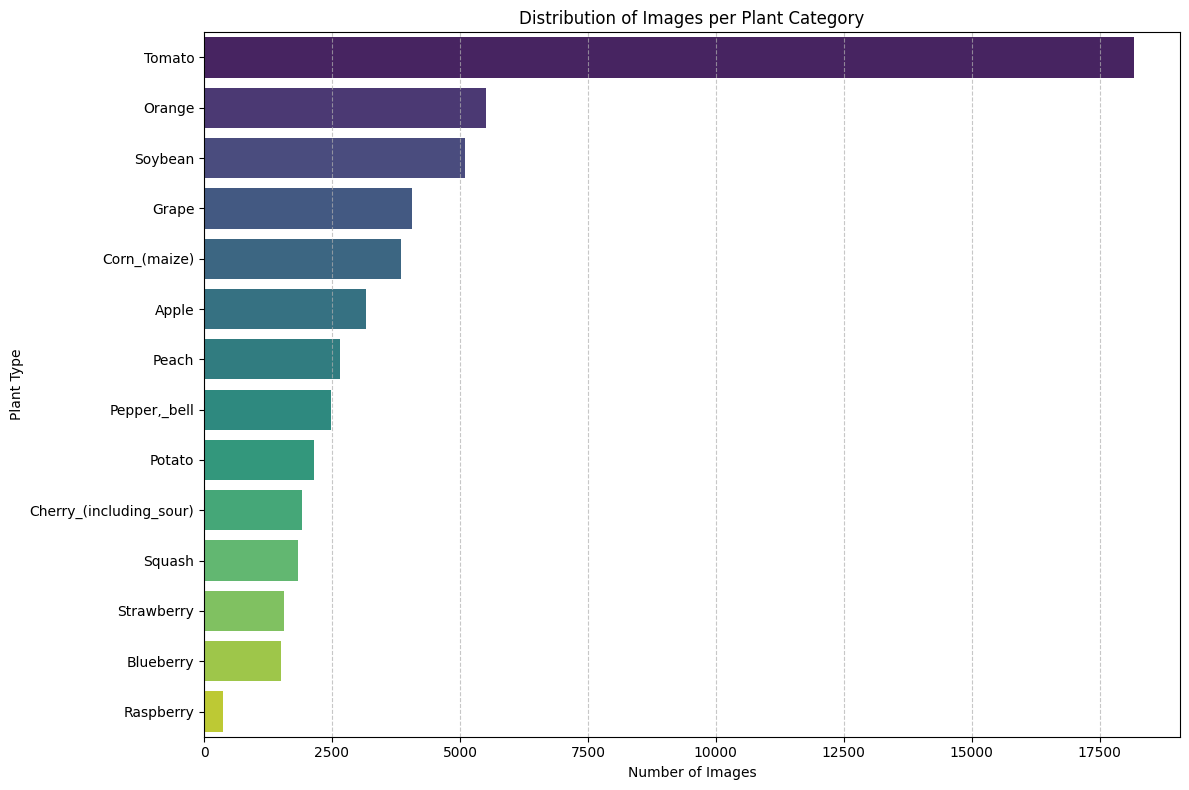

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert plant_counts dictionary to a DataFrame for plotting
plant_counts_df = pd.DataFrame(plant_counts.items(), columns=['Plant', 'Image Count'])

# Sort the DataFrame by image count for better visualization
plant_counts_df = plant_counts_df.sort_values(by='Image Count', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Image Count', y='Plant', hue='Plant', data=plant_counts_df, palette='viridis', legend=False)
plt.title('Distribution of Images per Plant Category')
plt.xlabel('Number of Images')
plt.ylabel('Plant Type')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Tomato

In [15]:
import os

Tomato_classes = [cls for cls in os.listdir(dataset_path) if "tomato" in cls.lower()]

print("Tomato classes:")
for cls in Tomato_classes:
    print(cls)

Tomato classes:
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Bacterial_spot
Tomato___Septoria_leaf_spot
Tomato___Late_blight
Tomato___Target_Spot
Tomato___healthy
Tomato___Early_blight
Tomato___Leaf_Mold
Tomato___Tomato_mosaic_virus


### Tomato Classes Image Counts

In [16]:
tomato_data = []
for cls in Tomato_classes:
    path = os.path.join(dataset_path, cls)
    tomato_data.append({'Class': cls, 'Image Count': len(os.listdir(path))})

tomato_df = pd.DataFrame(tomato_data)
tomato_df = tomato_df.sort_values(by='Image Count', ascending=False)

display(tomato_df)

,Class,Image Count
0,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357
2,Tomato___Bacterial_spot,2127
4,Tomato___Late_blight,1909
3,Tomato___Septoria_leaf_spot,1771
1,Tomato___Spider_mites Two-spotted_spider_mite,1676
6,Tomato___healthy,1591
5,Tomato___Target_Spot,1404
7,Tomato___Early_blight,1000
8,Tomato___Leaf_Mold,952
9,Tomato___Tomato_mosaic_virus,373


### Tomato Classes Image Counts Visualization

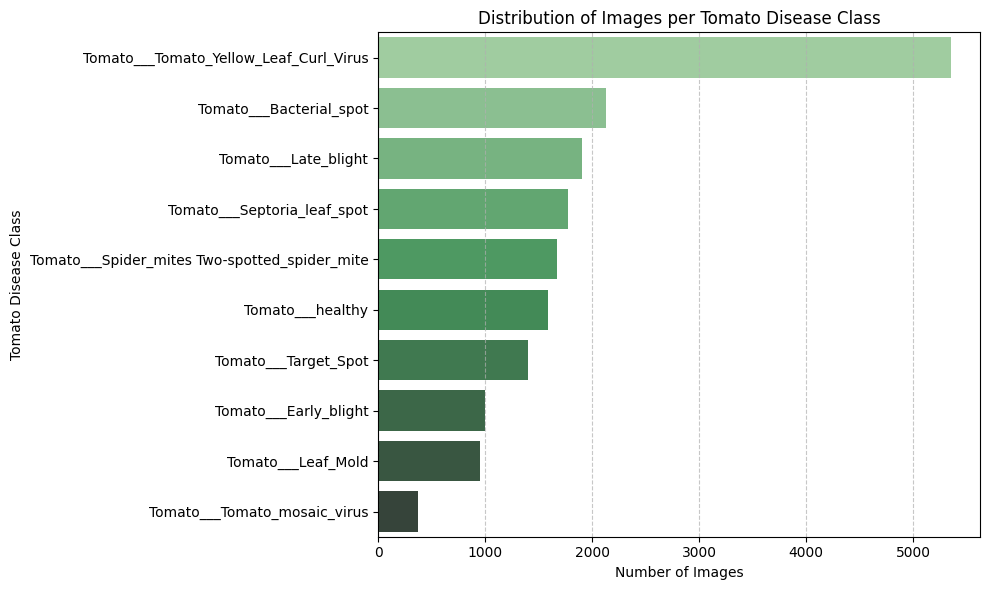

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Image Count', y='Class', hue='Class', data=tomato_df, palette='Greens_d', legend=False)
plt.title('Distribution of Images per Tomato Disease Class')
plt.xlabel('Number of Images')
plt.ylabel('Tomato Disease Class')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Image Preprocessing on Tomato plants

#🍅 1. Tomato Yellow Leaf Curl Virus

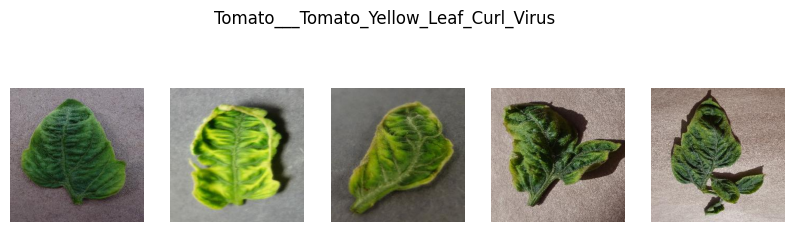

In [18]:
import os, cv2, matplotlib.pyplot as plt, random

cls = "Tomato___Tomato_Yellow_Leaf_Curl_Virus"
path = os.path.join(dataset_path, cls)

imgs = random.sample(os.listdir(path), 5)

plt.figure(figsize=(10,3))
for i, img_name in enumerate(imgs):
    img = cv2.imread(os.path.join(path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle(cls)
plt.show()

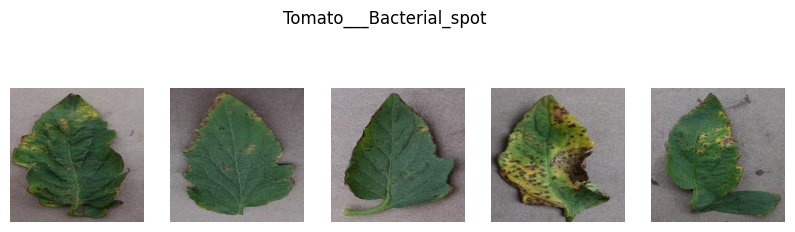

In [19]:
import os, cv2, matplotlib.pyplot as plt, random

cls = "Tomato___Bacterial_spot"
path = os.path.join(dataset_path, cls)

imgs = random.sample(os.listdir(path), 5)

plt.figure(figsize=(10,3))
for i, img_name in enumerate(imgs):
    img = cv2.imread(os.path.join(path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle(cls)
plt.show()

#🌧️ 3. Late Blight

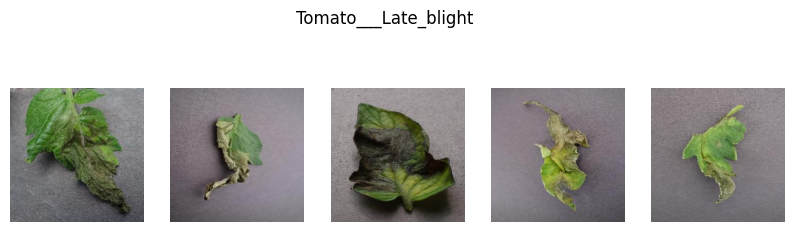

In [20]:
import os, cv2, matplotlib.pyplot as plt, random

cls = "Tomato___Late_blight"
path = os.path.join(dataset_path, cls)

imgs = random.sample(os.listdir(path), 5)

plt.figure(figsize=(10,3))
for i, img_name in enumerate(imgs):
    img = cv2.imread(os.path.join(path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle(cls)
plt.show()

#Tomato___healthy

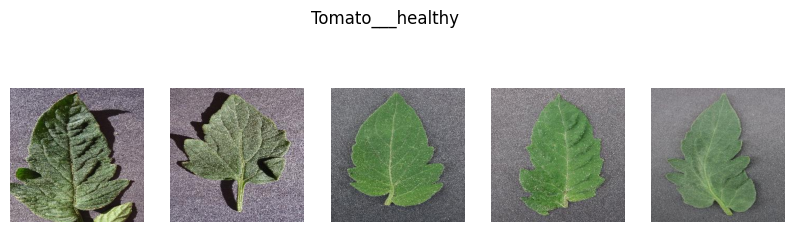

In [21]:
import os, cv2, matplotlib.pyplot as plt, random

cls = "Tomato___healthy"
path = os.path.join(dataset_path, cls)

imgs = random.sample(os.listdir(path), 5)

plt.figure(figsize=(10,3))
for i, img_name in enumerate(imgs):
    img = cv2.imread(os.path.join(path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle(cls)
plt.show()

#Data Augmentation

In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,              # your actual dataset path
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.


#Separate the Tomato Dataset from the folder

In [24]:
import os

os.makedirs("dataset/train", exist_ok=True)
os.makedirs("dataset/val", exist_ok=True)

In [25]:
import shutil
import random

for cls in Tomato_classes:
    src = os.path.join(dataset_path, cls)

    images = os.listdir(src)
    random.shuffle(images)

    split = int(0.8 * len(images))

    train_imgs = images[:split]
    val_imgs = images[split:]

    os.makedirs(f"dataset/train/{cls}", exist_ok=True)
    os.makedirs(f"dataset/val/{cls}", exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(src, img), f"dataset/train/{cls}")

    for img in val_imgs:
        shutil.copy(os.path.join(src, img), f"dataset/val/{cls}")

In [26]:
train_data = train_gen.flow_from_directory(
    "dataset/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_data = train_gen.flow_from_directory(
    "dataset/val",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 14523 images belonging to 10 classes.
Found 3637 images belonging to 10 classes.


In [27]:
print(train_data.class_indices)

{'Tomato___Bacterial_spot': 0, 'Tomato___Early_blight': 1, 'Tomato___Late_blight': 2, 'Tomato___Leaf_Mold': 3, 'Tomato___Septoria_leaf_spot': 4, 'Tomato___Spider_mites Two-spotted_spider_mite': 5, 'Tomato___Target_Spot': 6, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 7, 'Tomato___Tomato_mosaic_virus': 8, 'Tomato___healthy': 9}


#Build Model (MobileNetV2)

In [28]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [29]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
448/454 ━━━━━━━━━━━━━━━━━━━━ 2s 409ms/step - accuracy: 0.6543 - loss: 1.0589